# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [1]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
%pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [ ]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

In [6]:
from pathlib import Path
import zipfile

# Lab 4 folder
base_dir = Path(r"E:\python_project\output")

# Find ZIP files
zip_files = list(base_dir.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(f"No ZIP file found in {base_dir}")

# Use the first ZIP file found
zip_path = zip_files[0]

# Extraction folder
extract_dir = base_dir / "train_data"
extract_dir.mkdir(parents=True, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("ZIP file:", zip_path.name)
print("Extracted to:", extract_dir)

ZIP file: train.zip
Extracted to: E:\python_project\output\train_data


With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [7]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: E:\python_project\output\train_data\s2_image
Found mask dir: E:\python_project\output\train_data\mask


C:\Users\sifat\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (WindowsPath('E:/python_project/output/train_data/s2_image/train_s2_image_0.tif'), WindowsPath('E:/python_project/output/train_data/mask/train_mask_0.tif'))


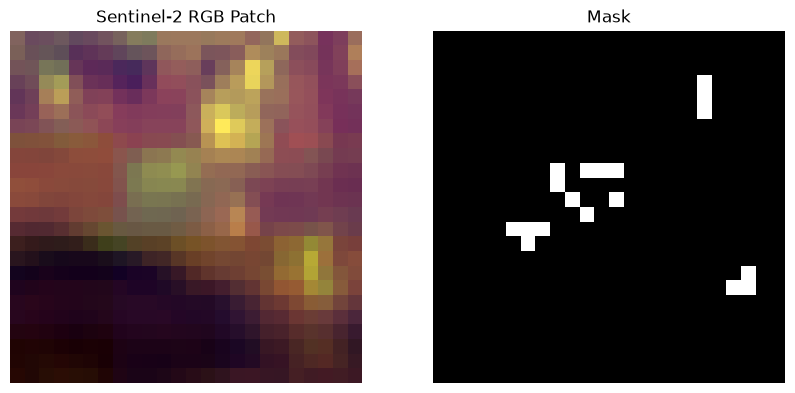

In [8]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [9]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████████████████████████████████████████████████████████████| 2066/2066 [03:18<00:00, 10.41it/s]


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [10]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

**Answer** Sentinel-2’s Multispectral Instrument (MSI) has 13 spectral bands in total, so in principle all 13 could be provided as input channels to the CNN rather than only the 3 RGB bands used here.

Next we find our patch files:

In [11]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

**Answer**: As per notebook parameter each .npz file normally contains 100 patches.
So:
Training set: 5 times 100 = 500 patches
Validation set: 2 times 100 = 200 patches

500 training patches and 200 validation patches.


We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [14]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [13]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [15]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?

**Answer:** Yes, the training dataset is shuffled, while the validation dataset is not shuffled. The training pipeline uses **shuffle=True**, which randomizes the order of the samples before they are passed to the model. This helps reduce the chance that the model learns patterns caused by the original ordering of the data. In contrast, the validation pipeline uses **shuffle=False**, so the validation samples remain in a fixed order for consistent evaluation.

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [17]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?

**Answer:** The final layer uses the sigmoid activation function. Sigmoid converts the output into a value between 0 and 1, which is appropriate because this is a binary classification problem: a patch either contains solar panels (1) or does not (0). The single output can therefore be interpreted as the model’s confidence/probability for the positive class. Sigmoid is also appropriate with the binary cross-entropy loss used in this model, since that loss can operate on predicted probabilities in the range \([0,1]\).

With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [18]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [19]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5


C:\Users\sifat\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9180 - loss: 0.3820 - val_accuracy: 0.9150 - val_loss: 0.2964
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9340 - loss: 0.2582 - val_accuracy: 0.9150 - val_loss: 0.2978
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9340 - loss: 0.2575 - val_accuracy: 0.9150 - val_loss: 0.2968
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9340 - loss: 0.2552 - val_accuracy: 0.9150 - val_loss: 0.3062


Visualizie the predictions:

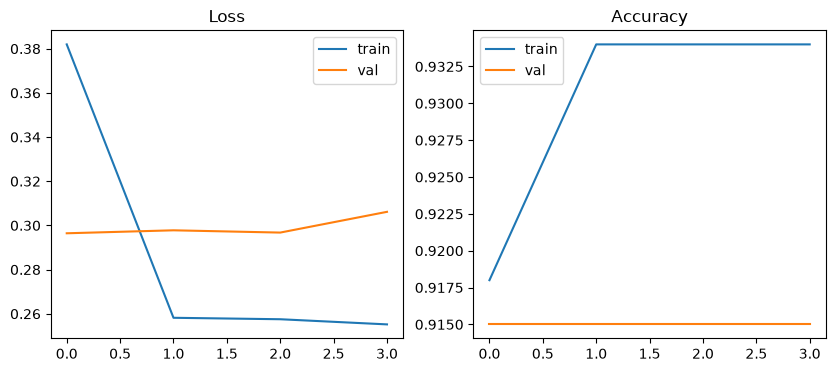

In [20]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

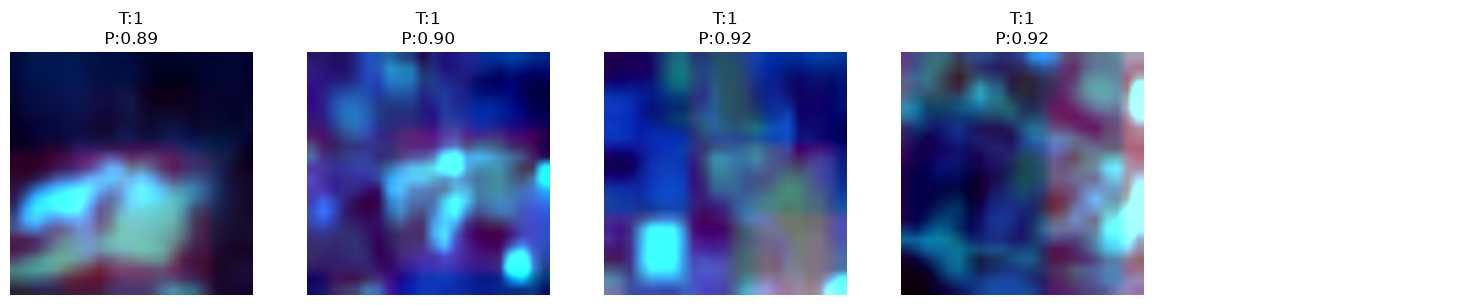

In [21]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

**Answer:** No, this is **not yet a robust or reliable model for detecting solar panels in completely unseen Sentinel-2 imagery**. The main weakness is the training-data design: the patches used here are effectively **positive examples containing solar panels**, so the CNN has not properly learned how to distinguish solar-panel patches from realistic negative patches. The model is also deliberately small and simplified, using only **3 RGB bands**, **128 × 128 inputs**, **6,177 trainable parameters**, a limited subset of about **500 training and 200 validation patches**, and at most **5 epochs**. Although the displayed validation examples receive high probabilities of about **0.89–0.92** for the correct positive class, this does not demonstrate that the model would avoid false positives on images without solar panels. A reliable model would need a balanced set of positive and negative examples, a more independent test set from unseen locations, and broader evaluation metrics such as precision, recall, F1-score, and confusion-matrix results.

**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).



**Answer:** The main weakness in the original training set is that almost all patches are positive examples: a patch is labelled 1 whenever its mask contains at least one solar-panel pixel. For a patch-based classifier, this means the model has very little opportunity to learn what “no solar panel” looks like and could achieve apparently good performance simply by predicting the positive class. I would redesign the training data by retaining the existing solar-panel patches as positive samples and adding a comparable number of negative patches where the mask contains no solar-panel pixels. These negatives should include difficult backgrounds such as rooftops, industrial areas, roads, parking areas and other bright surfaces that could visually resemble solar panels. When additional Sentinel-2 scenes are sampled, I would also apply the cloud/cloud-shadow filtering used in Lab 3 before extracting patches. Training, validation and test data should be separated by scene or geographic area before patch extraction, rather than randomly splitting nearby patches, to reduce spatial leakage and provide a more realistic test of generalisation. The training set can be approximately balanced between positive and negative samples, while the independent validation/test set should contain both classes and ideally reflect realistic conditions. I would initially retain the same 128 × 128 input size and RGB bands so that the effect of fixing the training-data design can be isolated; a later experiment could add additional Sentinel-2 spectral information such as NIR or SWIR after confirming the band order and appropriately resampling bands with different native resolutions. Sentinel-2 MSI provides visible, NIR and SWIR information at different spatial resolutions, so these additional channels are available for such experiments.

In [24]:
from pathlib import Path
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

TARGET_SIZE = 128
N_EXAMPLES = 4

# Output directories
robust_dir = base_dir / "robust_train_data"
positive_dir = robust_dir / "positive"
negative_dir = robust_dir / "negative"

positive_dir.mkdir(parents=True, exist_ok=True)
negative_dir.mkdir(parents=True, exist_ok=True)


def resize_patch(img, size=128):
    """Resize image patch to the CNN input size."""
    return cv2.resize(
        img,
        (size, size),
        interpolation=cv2.INTER_LINEAR
    )


def find_negative_crop(img, mask, attempts=500):
    """
    Find a region containing no labelled solar-panel pixels.
    The selected region is resized later to 128 × 128.
    """

    h, w = mask.shape

    # Binary solar-panel mask
    solar = (mask > 0).astype(np.uint8)

    # Small exclusion buffer around labelled panels
    kernel = np.ones((3, 3), np.uint8)
    exclusion = cv2.dilate(solar, kernel, iterations=1)

    # Try progressively smaller crop sizes
    crop_fractions = [0.5, 0.4, 0.3, 0.25]

    for fraction in crop_fractions:

        crop_h = max(4, int(h * fraction))
        crop_w = max(4, int(w * fraction))

        if crop_h > h or crop_w > w:
            continue

        for _ in range(attempts):

            y = rng.integers(0, h - crop_h + 1)
            x = rng.integers(0, w - crop_w + 1)

            mask_crop = exclusion[
                y:y + crop_h,
                x:x + crop_w
            ]

            # Accept only regions with no solar-panel pixels
            if np.sum(mask_crop) == 0:

                img_crop = img[
                    y:y + crop_h,
                    x:x + crop_w,
                    :
                ]

                return resize_patch(img_crop, TARGET_SIZE)

    return None


# Reset containers
positive_examples = []
negative_examples = []

positive_count = 0
negative_count = 0


for s2_path, mask_path in tqdm(pairs, desc="Creating robust dataset"):

    # Load Sentinel-2 image
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)
        img = np.transpose(img, (1, 2, 0))

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # -------------------------
    # Positive patch
    # -------------------------
    if np.any(mask > 0):

        positive_patch = resize_patch(img, TARGET_SIZE)

        np.save(
            positive_dir / f"positive_{positive_count:04d}.npy",
            positive_patch
        )

        if len(positive_examples) < N_EXAMPLES:
            positive_examples.append(positive_patch)

        positive_count += 1

    # -------------------------
    # Negative patch
    # -------------------------
    negative_patch = find_negative_crop(img, mask)

    if negative_patch is not None:

        np.save(
            negative_dir / f"negative_{negative_count:04d}.npy",
            negative_patch
        )

        if len(negative_examples) < N_EXAMPLES:
            negative_examples.append(negative_patch)

        negative_count += 1


print("Positive patches created:", positive_count)
print("Negative patches created:", negative_count)
print("Positive examples for figure:", len(positive_examples))
print("Negative examples for figure:", len(negative_examples))

Creating robust dataset: 100%|████████████████████████████████████████████████████| 2066/2066 [00:16<00:00, 122.47it/s]

Positive patches created: 1920
Negative patches created: 2025
Positive examples for figure: 4
Negative examples for figure: 4


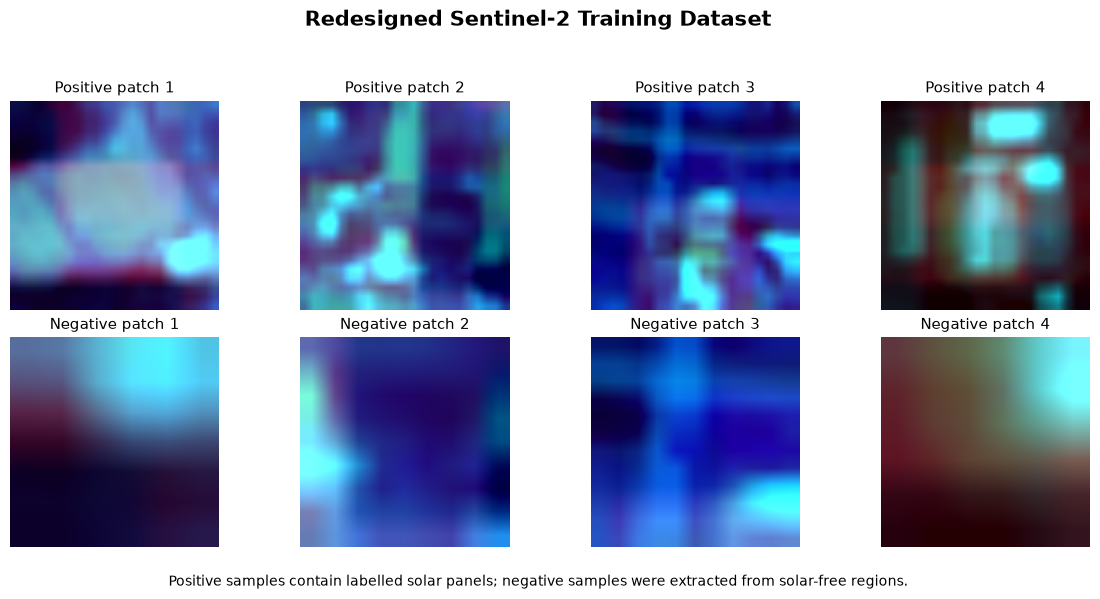

Figure saved to: E:\python_project\output\Q6_training_data_redesign.png


In [25]:
def stretch_rgb(img):
    """2–98 percentile stretch for visualisation."""
    img = img.astype(np.float32)

    p2, p98 = np.percentile(img, (2, 98))

    return np.clip(
        (img - p2) / (p98 - p2 + 1e-6),
        0,
        1
    )


n = min(
    N_EXAMPLES,
    len(positive_examples),
    len(negative_examples)
)

if n == 0:
    raise ValueError(
        "No positive/negative examples available. "
        "Check the dataset-generation step first."
    )


fig, axes = plt.subplots(
    2,
    n,
    figsize=(3 * n, 6),
    squeeze=False
)


for i in range(n):

    # Existing positive patch
    rgb_pos = stretch_rgb(
        positive_examples[i][..., :3]
    )

    axes[0, i].imshow(rgb_pos)
    axes[0, i].set_title(
        f"Positive patch {i + 1}",
        fontsize=11
    )
    axes[0, i].axis("off")

    # Newly generated negative patch
    rgb_neg = stretch_rgb(
        negative_examples[i][..., :3]
    )

    axes[1, i].imshow(rgb_neg)
    axes[1, i].set_title(
        f"Negative patch {i + 1}",
        fontsize=11
    )
    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Existing\nsolar-panel\nsamples",
    fontsize=11,
    fontweight="bold"
)

axes[1, 0].set_ylabel(
    "New\nnon-solar\nsamples",
    fontsize=11,
    fontweight="bold"
)


fig.suptitle(
    "Redesigned Sentinel-2 Training Dataset",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.5,
    0.02,
    "Positive samples contain labelled solar panels; "
    "negative samples were extracted from solar-free regions.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0.02, 0.06, 1, 0.94])

figure_path = base_dir / "Q6_training_data_redesign.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

**Answer:** **Changes made and reasoning-** The redesigned model was trained using a revised dataset containing both positive solar-panel patches and newly generated negative patches taken from areas where no solar-panel pixels were present. A small exclusion buffer was used around labelled solar panels so that negative samples were not taken immediately beside positive objects. This addresses the main weakness of the original patch-based training set, which contained predominantly positive examples and therefore gave the CNN little opportunity to learn the appearance of the negative class. The positive and negative samples were balanced as closely as possible and then separated into training and validation subsets. I retained the 128 × 128 input size and three RGB bands so that the effect of changing the training-data design could be assessed without simultaneously changing the spectral input. The CNN architecture was also kept the same for comparability, while the training settings were increased from a batch size of 4 to 8, the maximum number of epochs from 5 to 15, and early-stopping patience from 3 to 4 epochs. The redesigned run used all available selected positive and negative patches rather than restricting training to only five stored batch files.

**Model evaluation:** The redesigned model achieved a validation accuracy of 71.7%, loss of 0.5362, AUC of 0.8062, precision of 0.7463, and recall of 0.6589 for the solar-panel class. The balanced validation set contained 384 samples from each class, with the confusion matrix showing 298 true negatives, 253 true positives, 86 false positives and 131 false negatives. This indicates that the model has learned useful discriminatory information rather than simply predicting that every patch contains a solar panel, which was the major weakness of the original training design. However, recall for the solar-panel class remains relatively low at 65.9%, meaning that a substantial number of real solar-panel patches are still missed, while the non-solar class achieves a higher recall of 77.6%. The AUC of 0.8062 suggests reasonable class separation, but the model is not yet sufficiently robust for operational detection on unseen Sentinel-2 scenes. Nevertheless, the revised dataset produces a much more informative and realistic evaluation of generalisation than the original positive-dominated training setup.

In [26]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------
# Training settings
# ---------------------------------------------------------

TARGET_HEIGHT = 128
TARGET_WIDTH = 128
BANDS = 3

BATCH_SIZE = 8
EPOCHS = 15

# ---------------------------------------------------------
# Collect positive and negative samples
# ---------------------------------------------------------

positive_files = sorted(positive_dir.glob("*.npy"))
negative_files = sorted(negative_dir.glob("*.npy"))

# Balance the two classes
n_class = min(len(positive_files), len(negative_files))

rng = np.random.default_rng(SEED)

positive_files = list(
    rng.choice(positive_files, n_class, replace=False)
)

negative_files = list(
    rng.choice(negative_files, n_class, replace=False)
)

all_files = positive_files + negative_files
all_labels = [1] * n_class + [0] * n_class

# ---------------------------------------------------------
# Stratified train/validation split
# ---------------------------------------------------------

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

train_paths = [str(p) for p in train_paths]
val_paths = [str(p) for p in val_paths]

print("Training patches:", len(train_paths))
print("Validation patches:", len(val_paths))

# ---------------------------------------------------------
# Loader
# ---------------------------------------------------------

def load_patch(path, label):

    path = path.numpy().decode("utf-8")

    img = np.load(path).astype(np.float32)

    # First three bands only
    img = img[..., :BANDS]

    # Sentinel-2 reflectance normalization
    img = img / 10000.0

    return img, np.float32(label)


def tf_load(path, label):

    img, label = tf.py_function(
        load_patch,
        [path, label],
        [tf.float32, tf.float32]
    )

    img.set_shape(
        [TARGET_HEIGHT, TARGET_WIDTH, BANDS]
    )

    label.set_shape([])

    return img, label


# ---------------------------------------------------------
# TensorFlow datasets
# ---------------------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = (
    train_ds
    .shuffle(len(train_paths), seed=SEED)
    .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = (
    val_ds
    .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ---------------------------------------------------------
# Same CNN architecture for fair comparison
# ---------------------------------------------------------

inputs = layers.Input(
    shape=(TARGET_HEIGHT, TARGET_WIDTH, BANDS)
)

x = layers.Conv2D(
    16, 3,
    activation="relu",
    padding="same"
)(inputs)

x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(
    32, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    32,
    activation="relu"
)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model_new = models.Model(inputs, outputs)

model_new.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# ---------------------------------------------------------
# Early stopping
# ---------------------------------------------------------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

# ---------------------------------------------------------
# Train
# ---------------------------------------------------------

history_new = model_new.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ---------------------------------------------------------
# Final validation statistics
# ---------------------------------------------------------

results = model_new.evaluate(
    val_ds,
    return_dict=True
)

print("\nFinal validation results:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Training patches: 3072
Validation patches: 768
Epoch 1/15


C:\Users\sifat\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5111 - auc: 0.5171 - loss: 0.6929 - precision: 0.5092 - recall: 0.6120 - val_accuracy: 0.5456 - val_auc: 0.5806 - val_loss: 0.6912 - val_precision: 0.5243 - val_recall: 0.9844
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5690 - auc: 0.5736 - loss: 0.6870 - precision: 0.5513 - recall: 0.7422 - val_accuracy: 0.5742 - val_auc: 0.6055 - val_loss: 0.6783 - val_precision: 0.5638 - val_recall: 0.6562
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5957 - auc: 0.6200 - loss: 0.6645 - precision: 0.5755 - recall: 0.7298 - val_accuracy: 0.5977 - val_auc: 0.6887 - val_loss: 0.6560 - val_precision: 0.5589 - val_recall: 0.9271
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6035 - auc: 0.6510 - loss: 0.6493 - precision: 0.5723 - recall: 0.8190 - val_accuracy: 0.5977 - val_auc: 0.7011 - val_loss: 0.6364 - val_precision: 0.5614 - val_recall: 0.8932
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [27]:
# ---------------------------------------------------------
# Predictions and confusion matrix
# ---------------------------------------------------------

y_true = []
y_prob = []

for X, Y in val_ds:

    predictions = model_new.predict(
        X,
        verbose=0
    ).flatten()

    y_true.extend(Y.numpy())
    y_prob.extend(predictions)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        digits=3
    )
)


Confusion matrix:
[[298  86]
 [131 253]]

Classification report:
              precision    recall  f1-score   support

           0      0.695     0.776     0.733       384
           1      0.746     0.659     0.700       384

    accuracy                          0.717       768
   macro avg      0.720     0.717     0.716       768
weighted avg      0.720     0.717     0.716       768



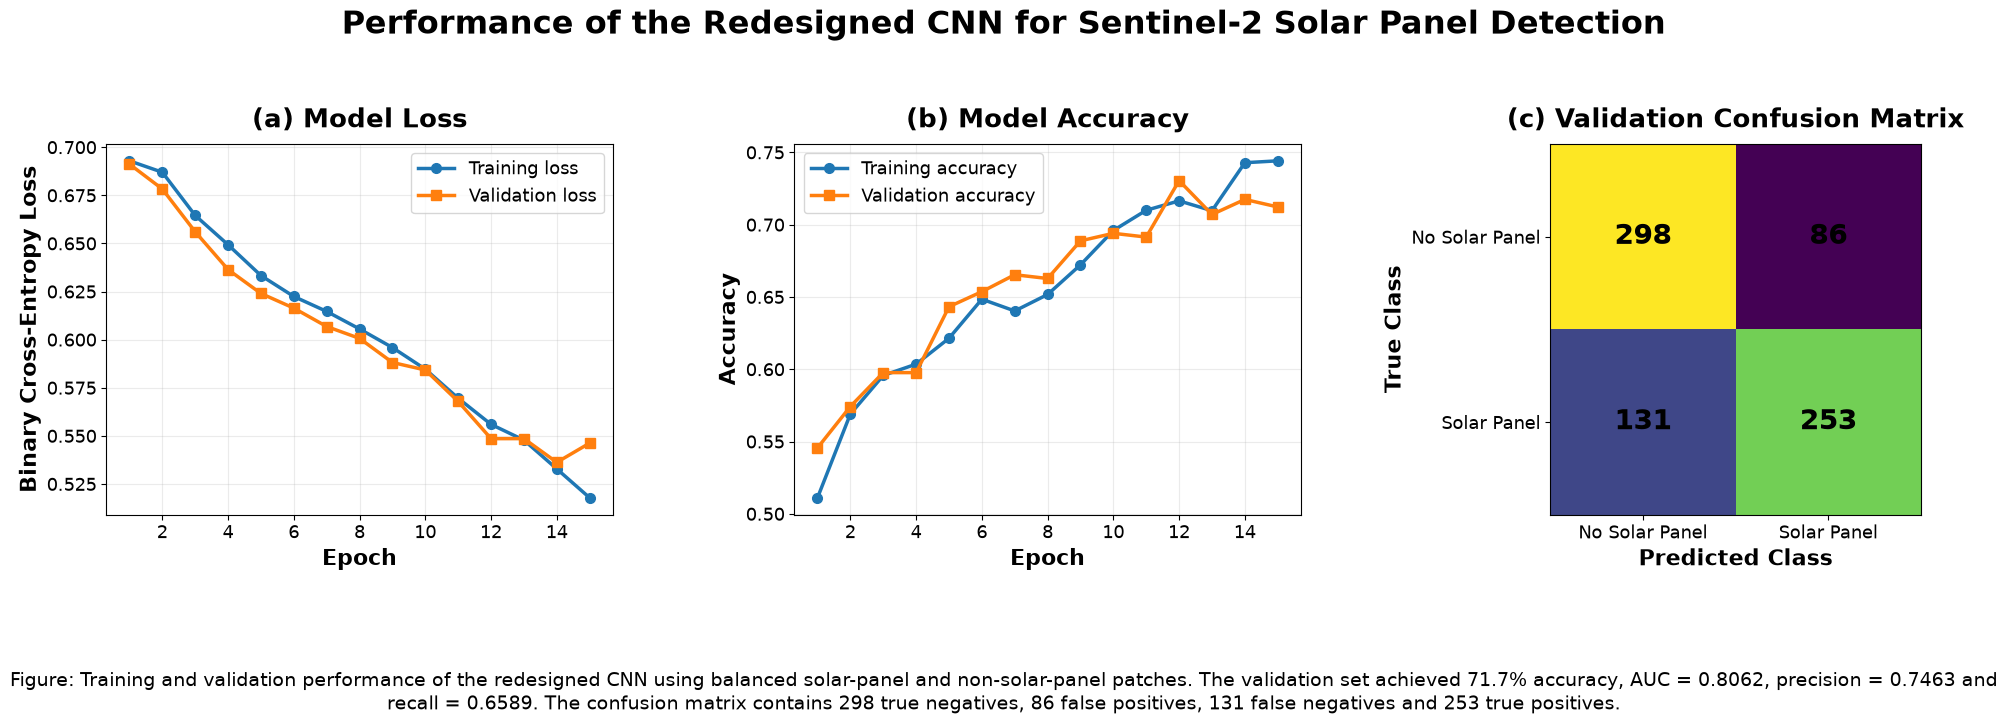

Publication-quality figure saved to:
E:\python_project\output\Q7_CNN_performance_publication.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

epochs = np.arange(
    1,
    len(history_new.history["loss"]) + 1
)

train_loss = history_new.history["loss"]
val_loss = history_new.history["val_loss"]

train_acc = history_new.history["accuracy"]
val_acc = history_new.history["val_accuracy"]

cm = confusion_matrix(y_true, y_pred)


# ---------------------------------------------------------
# Create publication-quality figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)


# =========================================================
# A. Training and validation loss
# =========================================================

axes[0].plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Training loss"
)

axes[0].plot(
    epochs,
    val_loss,
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Validation loss"
)

axes[0].set_title(
    "(a) Model Loss",
    fontsize=19,
    fontweight="bold",
    pad=12
)

axes[0].set_xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Binary Cross-Entropy Loss",
    fontsize=16,
    fontweight="bold"
)

axes[0].tick_params(
    axis="both",
    labelsize=13
)

axes[0].legend(
    fontsize=13,
    frameon=True
)

axes[0].grid(
    alpha=0.25
)


# =========================================================
# B. Training and validation accuracy
# =========================================================

axes[1].plot(
    epochs,
    train_acc,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Training accuracy"
)

axes[1].plot(
    epochs,
    val_acc,
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Validation accuracy"
)

axes[1].set_title(
    "(b) Model Accuracy",
    fontsize=19,
    fontweight="bold",
    pad=12
)

axes[1].set_xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Accuracy",
    fontsize=16,
    fontweight="bold"
)

axes[1].tick_params(
    axis="both",
    labelsize=13
)

axes[1].legend(
    fontsize=13,
    frameon=True
)

axes[1].grid(
    alpha=0.25
)


# =========================================================
# C. Confusion matrix
# =========================================================

im = axes[2].imshow(cm)

axes[2].set_title(
    "(c) Validation Confusion Matrix",
    fontsize=19,
    fontweight="bold",
    pad=12
)

axes[2].set_xlabel(
    "Predicted Class",
    fontsize=16,
    fontweight="bold"
)

axes[2].set_ylabel(
    "True Class",
    fontsize=16,
    fontweight="bold"
)

axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])

axes[2].set_xticklabels(
    ["No Solar Panel", "Solar Panel"],
    fontsize=13
)

axes[2].set_yticklabels(
    ["No Solar Panel", "Solar Panel"],
    fontsize=13
)


# Add count inside each confusion-matrix cell
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        axes[2].text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold"
        )


# ---------------------------------------------------------
# Overall title
# ---------------------------------------------------------

fig.suptitle(
    "Performance of the Redesigned CNN for Sentinel-2 Solar Panel Detection",
    fontsize=23,
    fontweight="bold",
    y=1.02
)


# ---------------------------------------------------------
# Figure caption
# ---------------------------------------------------------

caption = (
    "Figure: Training and validation performance of the redesigned CNN using "
    "balanced solar-panel and non-solar-panel patches. "
    "The validation set achieved 71.7% accuracy, AUC = 0.8062, "
    "precision = 0.7463 and recall = 0.6589. "
    "The confusion matrix contains 298 true negatives, 86 false positives, "
    "131 false negatives and 253 true positives."
)

fig.text(
    0.5,
    -0.08,
    caption,
    ha="center",
    va="top",
    fontsize=14,
    wrap=True
)


# ---------------------------------------------------------
# Layout and save
# ---------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.06, 1, 0.96]
)

figure_path = base_dir / "Q7_CNN_performance_publication.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Publication-quality figure saved to:")
print(figure_path)